# ANALYSIS OF RV CANTEEN FEEDBACK DATASET - DAP  MINI PROJECT

#### BY - ARJUN SYAM, ANIKETH BHARGAV, AKSHATA ATHREYA , AHAAN R

### IMPORTED MODULES :-

In [1]:
#pandas is used for basic statistical analysis
#seaborn used here for heatmaps 
#matplotlib used here for basic graphs like bar, pie etc
#statsmodels used for creation of mosaic plot
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.graphics.mosaicplot import mosaic

### READING THE DATASET :-

In [2]:
#cleaning of the dataset done in another file named RVFOOD_dataset_conversion
#opening the csv dataset using pandas read_csv
df = pd.read_csv("RV_food_dataset.csv")
df

,Unnamed: 0,Timestamp,Are You From RVU or RVCE,Gender,Veg/Non Veg,Prefered cuisine,Go to Beverage,Mingos Rating,Thoda Aur Rating,How much you spend on average breakfast/snacks daily,How much you spend on lunch daily,Average waiting time(minutes)
0,0,18/12/2023 21:21:11,RVU,Female,Non Veg,North Indian,Chia seed juice,4,5,20,60,7
1,1,18/12/2023 21:23:03,RVU,Male,Non Veg,Biryani,Aerated beverages,4,5,50,160,9
2,2,18/12/2023 21:23:20,RVU,Male,Non Veg,Biryani,Fruit juice,3,3,80,80,12
3,3,18/12/2023 21:29:11,RVU,Male,Non Veg,Biryani,Aerated beverages,5,5,190,320,6
4,4,18/12/2023 21:30:40,RVU,Male,Non Veg,Chinese,Energy drinks,5,5,80,90,8
...,...,...,...,...,...,...,...,...,...,...,...,...
152,152,19/12/2023 17:48:41,RVCE,Male,Veg,South Indian,Tea/coffee,4,3,70,80,4
153,153,19/12/2023 18:40:45,RVCE,Female,Veg,Chinese,Tea/coffee,2,4,20,50,7
154,154,19/12/2023 18:52:52,RVU,Female,Veg,Fast food,Tea/coffee,4,4,40,50,7
155,155,19/12/2023 18:58:09,RVCE,Male,Veg,Fast food,Fruit juice,4,4,30,50,8


In [3]:
#Dropping all unused coloumns in dataset
df = df.drop(['Unnamed: 0','Timestamp'], axis=1)
df

,Are You From RVU or RVCE,Gender,Veg/Non Veg,Prefered cuisine,Go to Beverage,Mingos Rating,Thoda Aur Rating,How much you spend on average breakfast/snacks daily,How much you spend on lunch daily,Average waiting time(minutes)
0,RVU,Female,Non Veg,North Indian,Chia seed juice,4,5,20,60,7
1,RVU,Male,Non Veg,Biryani,Aerated beverages,4,5,50,160,9
2,RVU,Male,Non Veg,Biryani,Fruit juice,3,3,80,80,12
3,RVU,Male,Non Veg,Biryani,Aerated beverages,5,5,190,320,6
4,RVU,Male,Non Veg,Chinese,Energy drinks,5,5,80,90,8
...,...,...,...,...,...,...,...,...,...,...
152,RVCE,Male,Veg,South Indian,Tea/coffee,4,3,70,80,4
153,RVCE,Female,Veg,Chinese,Tea/coffee,2,4,20,50,7
154,RVU,Female,Veg,Fast food,Tea/coffee,4,4,40,50,7
155,RVCE,Male,Veg,Fast food,Fruit juice,4,4,30,50,8


In [4]:
#Printing all coloumn names in the dataset
df.keys()

Index(['Are You From RVU or RVCE', 'Gender', 'Veg/Non Veg', 'Prefered cuisine',
       'Go to Beverage', 'Mingos Rating', 'Thoda Aur Rating',
       'How much you spend on average breakfast/snacks daily',
       'How much  you spend on lunch daily', 'Average waiting time(minutes)'],
      dtype='object')

### 1) AVERAGE SPENT ON LUNCH AMONG DIFFERENT CUSINES

Prefered cuisine
Biryani         124.375000
Chaats           78.666667
Chinese         107.142857
Fast food       118.387097
North Indian    101.562500
South Indian     92.307692
Name: How much  you spend on lunch daily, dtype: float64


Text(0, 0.5, 'avg spent on lunch')

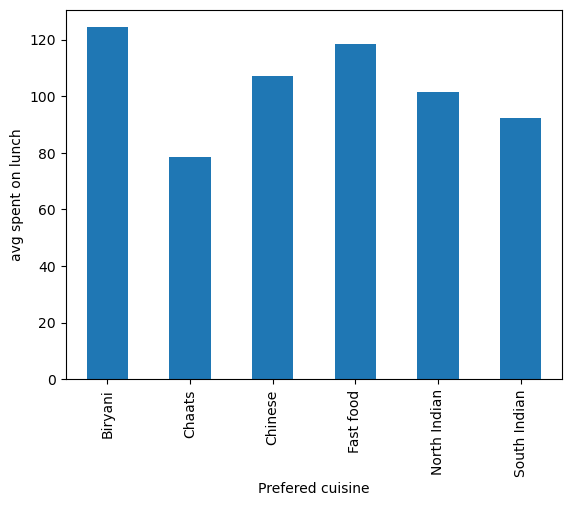

In [5]:
#here we are grouping the dataset by the coloumn preferred cuisine
dff = df.groupby('Prefered cuisine')
#after grouping the data by cuisine we are finding the mean of lunch spent daily for each cuisine type and ploting with bar plot
print(dff['How much  you spend on lunch daily'].mean())
dff['How much  you spend on lunch daily'].mean().plot.bar()
plt.ylabel('avg spent on lunch')

### Conclusions :

#### --> Looking at the provided data, the graph above shows the average amount students spend for their preferred cusines during lunch.
#### --> It appears that Biryani is the top preferred cuisine, followed closely by Fast Food and Chinese. North Indian and South Indian cuisines fall slightly behind, while Chaats seem to be the least preferred among these options.
#### -->  This suggests a strong inclination towards flavorful, aromatic dishes like Biryani and an appreciation for quick bites like Fast Food and Chinese cuisine.
#### --> Preferences might vary based on individual tastes and occasions, this also tells us how to adjust the pricing of each cuisine in order to match the average amounts students are willing to pay for each cuisine.



### 2) AVERAGE WAITING TIME FOR NON VEG AND VEG

Veg/Non Veg
Non Veg    7.789474
Veg        8.024691
Name: Average waiting time(minutes), dtype: float64


Text(0, 0.5, 'Avg waiting time(mins)')

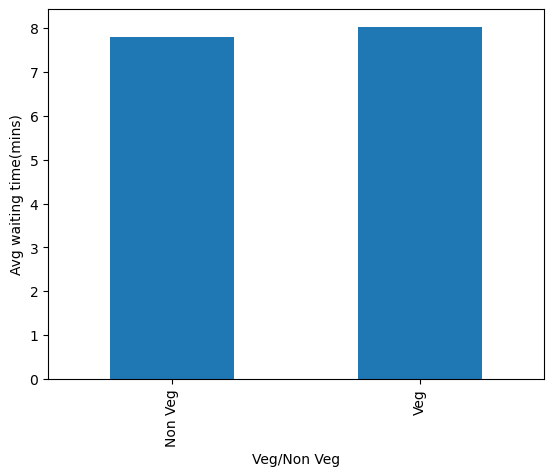

In [6]:
#here we are grouping the dataset by Veg and Non Veg
dff = df.groupby('Veg/Non Veg')
#After grouping we are finding the average waiting time for Vegetarians and Non vegetarians and ploting it with a bar plot
print(dff['Average waiting time(minutes)'].mean())
dff['Average waiting time(minutes)'].mean().plot.bar()
plt.ylabel('Avg waiting time(mins)')


### Conclusions :

#### --> From the provided data, it's apparent that there's a marginal difference in average waiting times between Veg and Non-Veg food.
#### -->  Non-Veg dishes seem to have a slightly higher average waiting time compared to Veg dishes, indicating that prepeation and delivery of the non veg counter has to be made more efficient.
#### --> Overall, the average time spend is around 8 mins, which means that a significant portion of the break time that students get for meals is spent waiting in queues.
#### --> The canteens can take this input and increase the staff to make the process more efficient and less time consuming, so that students can manage time and get to class accordingly.
 






### 3) CORRELATION BETWEEN NUMERIC COLOUMNS IN DATASET

In [7]:
#Here using df.select_dtypes we are first taking all the numerical coloumns only
df_corr = df.select_dtypes(np.number)
#after getting the numerical coloumns we are finding the correlation between all of them in the dataset
dff = df_corr.corr()
dff

,Mingos Rating,Thoda Aur Rating,How much you spend on average breakfast/snacks daily,How much you spend on lunch daily,Average waiting time(minutes)
Mingos Rating,1.000000,0.299473,-0.136878,-0.107263,-0.141186
Thoda Aur Rating,0.299473,1.000000,-0.073388,-0.077598,-0.028543
How much you spend on average breakfast/snacks daily,-0.136878,-0.073388,1.000000,0.585600,0.196666
How much you spend on lunch daily,-0.107263,-0.077598,0.585600,1.000000,0.290614
Average waiting time(minutes),-0.141186,-0.028543,0.196666,0.290614,1.000000


<Axes: >

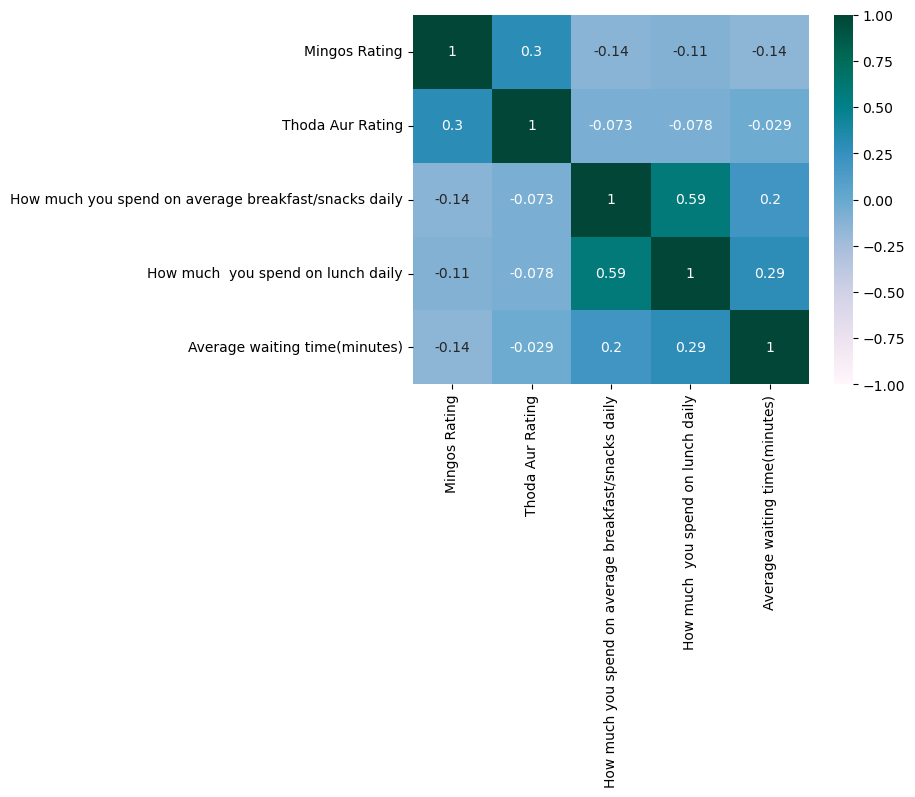

In [8]:
#sns from seaborn library to plot the heatmap
sns.heatmap(dff,cmap='PuBuGn',vmin =-1,vmax=1,annot=True)

### Conclusions :

#### --> Using a heatmap we are able to visually represent the correlation between the different numerical columns within the dataset.
#### --> From the heatmap we are able to gather that there is a positive correlation between various coloumns such as :
#### (a) How much is spent on lunch daily and the average spent on breakfast/snacks. This suggests that those people who are willing to spend more on lunch also tend to spend more on snacks.
#### (b) How much is spent on lunch daily and the average waiting time also have a very slight correlation, suggetsing that there is a slight chance that by spending more on lunch, you will need to wait longer for your food.











### 4) CHECKING THE SKEWNESS AND KURTOSIS OF AVG SPENT ON BREAKFAST/SNACKS DAILY

This distribution has skew 1.5531115327723437
This distribution has kurtosis 2.260515420795253
59.93630573248408


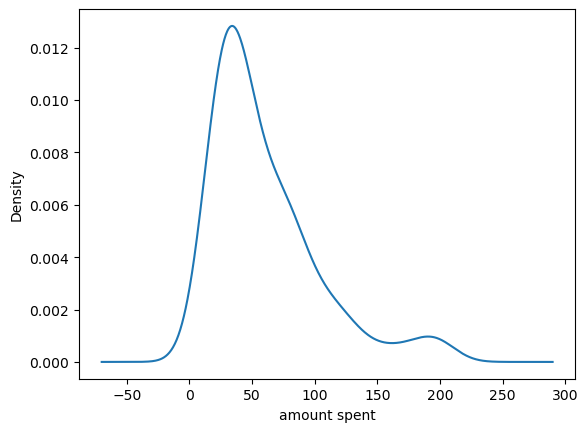

In [9]:
#Here we are plotting a denisity curve to visualize the skewness and kurtosis of avg spent on breakfast daily
df['How much you spend on average breakfast/snacks daily'].plot(kind = 'density')
plt.xlabel('amount spent')
#here we are calculating the skewness and kurtosis using .skew() and .kurt() functions from pandas
print('This distribution has skew',df['How much you spend on average breakfast/snacks daily'].skew())
print('This distribution has kurtosis',df['How much you spend on average breakfast/snacks daily'].kurt())
print(df['How much you spend on average breakfast/snacks daily'].mean())

### Conclusions :

#### --> Skewness and kurtosis are statistical measures that describe the shape of a probability distribution.
#### --> Skewness measures the asymmetry of the distribution and the data is extremely skewed as majority of the population spend an amount of Rs 0-100 daily in the canteen.
#### --> The density curve above indicates that majority of the population lies between the region(of spending) from 0-100, indicating that majority of the people spend in this range.
#### --> Kurtosis measures the tailedness or peakedness of a distribution compared to the normal distribution. The kurtosis value of 1.46 indicates that the data is lepto kurtic indicating that the curve has heavier tails, which implies that the data has extreme outliers deviating from the central spending value.
#### --> From this, we can say that average price for food should lie in the range Rs.50-100, as majority of the people spend in that range.






### 5) COMPARING THE AMOUNT SPENT ON LUNCH VS BREAKFAST/SNACKS DAILY USING BOXPLOT

median of spent on lunch is:  80.0
median of spent on bfast/snacks is:  40.0


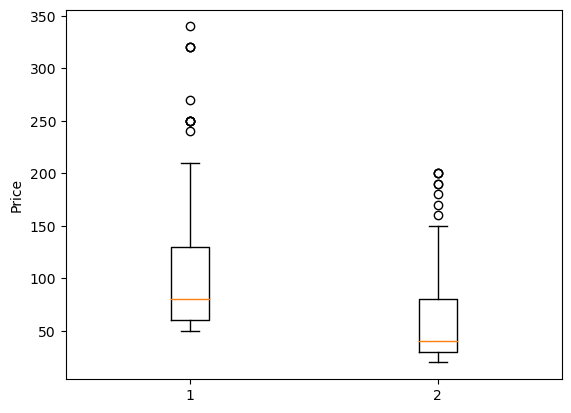

In [10]:
print("median of spent on lunch is: ",df['How much  you spend on lunch daily'].median())
print("median of spent on bfast/snacks is: ",df['How much you spend on average breakfast/snacks daily'].median())
plt.boxplot(df[['How much  you spend on lunch daily','How much you spend on average breakfast/snacks daily']])
plt.ylabel('Price')
plt.show()

### Conclusions :

#### --> The two box plots show that most people spend more for lunch(Rs.50-200) compared to bfast/snacks(Rs.20-140).
#### --> The median spending value for lunch is 70, whereas the median spending value for bfast is 40 Both the box plots have outliers, incdicating that some people spend beyond the normal range daily.
#### --> This data helps us understand the average budget of students, which can allow the canteens to adjust their prices accordingly to make it available at a reasonable price.





### 6) COMPARISION BETWEEN THE AVERAGE RATINGS OF MINGOS AND THODA AUR

3.4076433121019107
3.267515923566879


Text(0, 0.5, 'rating')

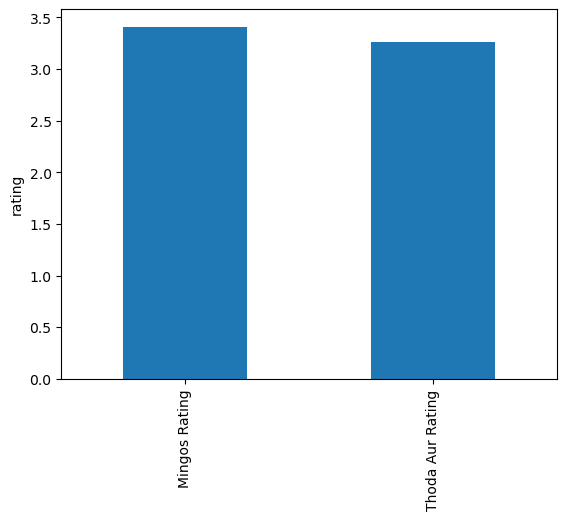

In [11]:
print(df['Mingos Rating'].mean())
print(df['Thoda Aur Rating'].mean())
df[['Mingos Rating','Thoda Aur Rating']].mean().plot.bar()
plt.ylabel("rating")

### Conclusions :

#### --> The above diagram is a bar plot representing the comparision between 'Thoda aur' and 'Mingos' ratings.
#### --> From this we can tell that both canteens are preferred and liked by the students of RVU and RVCE. But if we observe the mingos rating is a little higher than Thoda aur by this we can see there are more people who prefer mingos over thoda aur
#### --> As the difference in rating is not that great we can say that both these canteens have put up an equal competition for business and have been sustaining. 
#### --> We can also say that there is scope of improvement for both these canteens as they don't have an outstanding result.

### 7) DISTRIBUTION OF BEVERAGES USING PIECHART

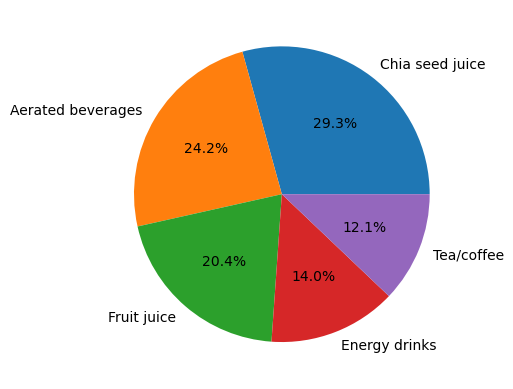

In [12]:
#to create the labels for the pie chart we take a list of all the beverage types by dropping the duplicates form 
#'go to beverage' coloumn and convert it to a list
beverage = df['Go to Beverage'].drop_duplicates().tolist()
plt.pie(df['Go to Beverage'].value_counts(),labels = beverage,autopct='%.1f%%')
plt.show()

### Conclusions :

#### --> Here using a pie chart we are able to visualize the distribution of bevrages that people like.
#### --> From the chart we can see that among people's favourite bevarage 29 % is composed of Chia seed juice, followed by Aerated bevarges with 24.2%, fuit juice with 20.4% and energy drinkks and tea/coffee occupying 14% and 12 % respectively.
#### --> Using this chart and dataset we can help the canteen reducde investing money on products which are in very low demand and invest more in fast moving products. As we can see Chia seed juice and aerated beverages are the fast moving we can advise them to get more variety in these and increase their demand and sale.
#### --> Using this data we can tell that while restocking beverages the canteens must focus a large part in restocking chia seed juice, aerated beverages.




### 8) COMPARING THE AVERAGE WAITING TIME BETWEEN MALES AND FEMALES

Gender
Female    5.603175
Male      9.457447
Name: Average waiting time(minutes), dtype: float64


Text(0, 0.5, 'Avg Waiting Time')

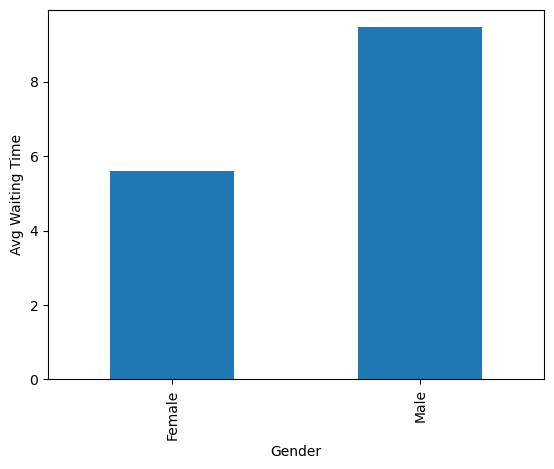

In [13]:
#here we are grouping the data by gender
dff = df.groupby('Gender')
#then we are plotting the avg waiting time for each gender
print(dff['Average waiting time(minutes)'].mean())
dff['Average waiting time(minutes)'].mean().plot.bar()
plt.ylabel("Avg Waiting Time")

### Conclusions :

#### --> The above diagram is a bar plot representing the comparision between waiting time for male and female.
#### --> As we can see there is a pretty large increase in waiting time for men than women. Thus, more males tend to wait longer for food as compared to females.
#### --> We can say that women are given a pretty higher privilege by reducing their waiting time which is a good thing for them. This shows disparity in treatment between men and women in service of food.

### 9) BEVERAGE PAIRING WITH EACH CUSINE FREQUENCY GRAPH

        cuisine  Aerated beverages  Chia seed juice  Energy drinks  \
0       Biryani                 11                4              1   
1        Chaats                  4                1              2   
2       Chinese                  5                4              1   
3     Fast food                  5                4              8   
4  North Indian                  6                7              2   
5  South Indian                  1                2              5   

   Fruit juice  Tea/coffee  
0           13           3  
1            5           3  
2            5           6  
3            6           8  
4            9           8  
5            8          10  


Text(0, 0.5, 'frequency')

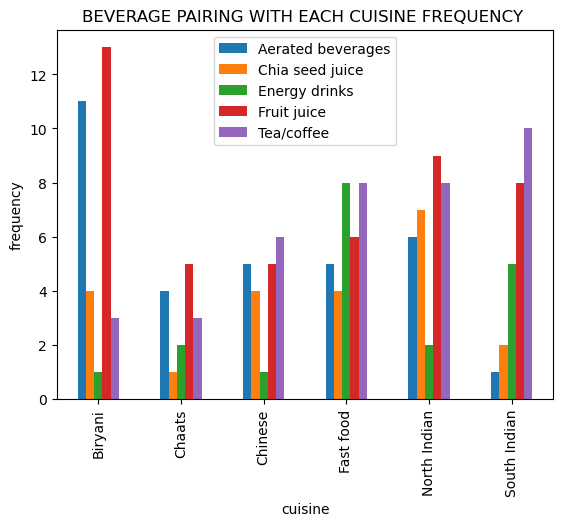

In [14]:

df_bev = df['Go to Beverage'].drop_duplicates()
#getting label names for all the values in graph
list_names = ['cuisine','Aerated beverages','Chia seed juice','Energy drinks','Fruit juice','Tea/coffee' ]

#biryani

#here we first get a dataframe for only biryani values
df_bir = df[df['Prefered cuisine'] == 'Biryani']
#then we group that data by beverages
df_bir_cusines = df_bir.groupby('Go to Beverage')
#then we find the value count for the each beverage qithin biryani and pass it as a list + the cusine heading at zeroth index
#and store this as list
list_bir = ['Biryani'] + df_bir_cusines['Go to Beverage'].value_counts().tolist()

#similarly we do the same for all cusines

#chaats
df_chaats = df[df['Prefered cuisine'] == 'Chaats']
df_chaats_cusines = df_chaats.groupby('Go to Beverage')
list_chaats = ['Chaats'] + df_chaats_cusines['Go to Beverage'].value_counts().tolist()

#chinese
df_chin = df[df['Prefered cuisine'] == 'Chinese']
df_chin_cusines = df_chin.groupby('Go to Beverage')
list_chin = ['Chinese'] + df_chin_cusines['Go to Beverage'].value_counts().tolist()

#fast food
df_fast = df[df['Prefered cuisine'] == 'Fast food']
df_fast_cusines = df_fast.groupby('Go to Beverage')
list_fast = ['Fast food'] + df_fast_cusines['Go to Beverage'].value_counts().tolist()

#North Indian
df_north = df[df['Prefered cuisine'] == 'North Indian']
df_north_cusines = df_north.groupby('Go to Beverage')
list_north = ['North Indian'] + df_north_cusines['Go to Beverage'].value_counts().tolist()

#South Indian
df_south = df[df['Prefered cuisine'] == 'South Indian']
df_south_cusines = df_south.groupby('Go to Beverage')
list_south = ['South Indian'] + df_south_cusines['Go to Beverage'].value_counts().tolist()


#we then pass the lists we created as a new dataframe with list_names as coloumn heading 
df_bev_cusine_bar = pd.DataFrame([list_bir, list_chaats, list_chin, 
                   list_fast,list_north,list_south], 
                  columns=list_names)

print(df_bev_cusine_bar)

#with this new dataframe we plot it as a graph
df_bev_cusine_bar.plot(x='cuisine', 
        kind='bar', 
        stacked=False, 
        title='BEVERAGE PAIRING WITH EACH CUISINE FREQUENCY ') 
plt.ylabel("frequency")

### Conclusions :

#### --> In the above frequency graph we are computing the most commonly chosen beverage paired with each cuisine , within the graph we can see that :
#### (a) the most popular beverage chosen along side Biryani is Fruit juice and Aerated drinks. 
#### (b) the most popular beverage chosen along side Chaats is Fruit juice and Aerated drinks. 
#### (c) the most popular beverage chosen along side Chinese food is Fruit juice and Aerated drinks.
#### (d) the most popular beverage chosen along side Fast Food is energy drinks and tea/coffee. 
#### (e) the most popular beverage chosen along side North Indian food is Fruit juice and tea/coffee.
#### (f) the most popular beverage chosen along side South Indian food is tea/coffee and Fruit juice.
#### --> This information can be used to make combo offers of food+beverages which can drive up the business for the canteens. 


### 10) VEG NON VEG COMPOSITION OF PEOPLE IN EACH CUISINE USING GRAPH

In [15]:
# This analysis is done in similar way as the previous analysis
df1= df.groupby('Prefered cuisine')
print(df1['Veg/Non Veg'].value_counts())

Prefered cuisine  Veg/Non Veg
Biryani           Non Veg        28
                  Veg             4
Chaats            Veg            13
                  Non Veg         2
Chinese           Non Veg        11
                  Veg            10
Fast food         Veg            16
                  Non Veg        15
North Indian      Veg            23
                  Non Veg         9
South Indian      Veg            15
                  Non Veg        11
Name: count, dtype: int64


Text(0, 0.5, 'frequency')

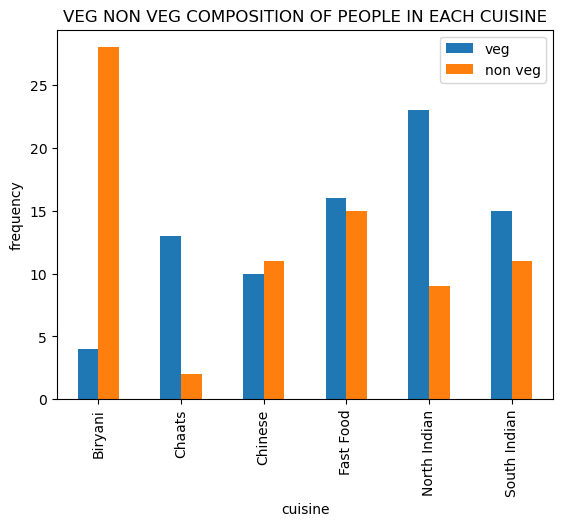

In [16]:

list_names = ['cuisine','veg','non veg']

#biryani
df_vegnonveg_bir = df[df['Prefered cuisine'] == 'Biryani']

list_vegnonveg_bir = ['Biryani'] + df_vegnonveg_bir['Veg/Non Veg'].value_counts().tolist()[::-1]

#chaats
df_vegnonveg_chat = df[df['Prefered cuisine'] == 'Chaats']

list_vegnonveg_chat = ['Chaats'] + df_vegnonveg_chat['Veg/Non Veg'].value_counts().tolist()


#chinese
df_vegnonveg_chin = df[df['Prefered cuisine'] == 'Chinese']

list_vegnonveg_chin = ['Chinese'] + df_vegnonveg_chin['Veg/Non Veg'].value_counts().tolist()[::-1]

#fast food
df_vegnonveg_fas = df[df['Prefered cuisine'] == 'Fast food']

list_vegnonveg_fas = ['Fast Food'] + df_vegnonveg_fas['Veg/Non Veg'].value_counts().tolist()


#north indian
df_vegnonveg_nor = df[df['Prefered cuisine'] == 'North Indian']

list_vegnonveg_nor = ['North Indian'] + df_vegnonveg_nor['Veg/Non Veg'].value_counts().tolist()


#south indian
df_vegnonveg_so = df[df['Prefered cuisine'] == 'South Indian']

list_vegnonveg_so = ['South Indian'] + df_vegnonveg_so['Veg/Non Veg'].value_counts().tolist()



df_bev_cusine_bar = pd.DataFrame([list_vegnonveg_bir,list_vegnonveg_chat,list_vegnonveg_chin,list_vegnonveg_fas,list_vegnonveg_nor,list_vegnonveg_so], 
                  columns=list_names)
df_bev_cusine_bar.plot(x='cuisine', 
        kind='bar', 
        stacked=False, 
        title='VEG NON VEG COMPOSITION OF PEOPLE IN EACH CUISINE') 
plt.ylabel("frequency")

### Conclusions :

#### --> Majority of the people prefer to buy non-veg biryani over veg biryani. Non-veg Chinese food is preferred over veg chinese food.
#### --> Veg fast food are preferred over non veg fast food. Both south and north indian meals are preferred in veg rather than non veg and Veg Chaats are preferred over Non-veg chaats , infact there is no non-veg chats in the canteen.
#### --> This tells that the canteens can focus on different supplies for different cuisines in order to produce the maximum preferred food (Veg or Non veg) under each cuisine and prepare for what's more in demand.







### 11) Finding the relation between gender and beverages

In [17]:
#finding the crosstab between gender and beverages
dfff = pd.crosstab(df['Gender'],df['Go to Beverage'])
dfff

Go to Beverage,Aerated beverages,Chia seed juice,Energy drinks,Fruit juice,Tea/coffee
Gender,,,,,
Female,12,11,6,16,18
Male,20,11,13,30,20


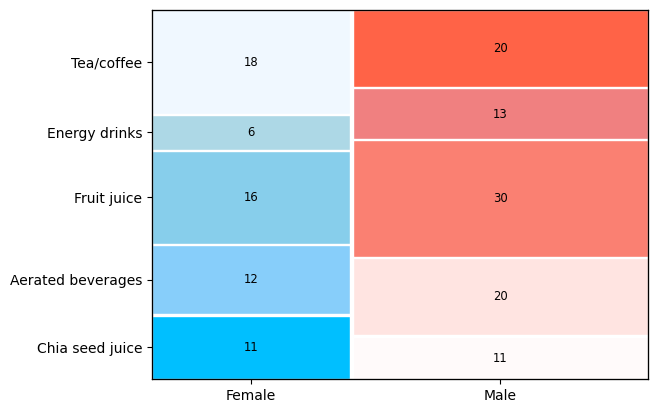

In [18]:
#creating a dictionary props to give attributes to each square such as color and edgecolor and paaing that into properties
#creating a labelizer to give the values of each area within the mosaic plot for better reading
props={}
props[('Female','Tea/coffee')]={'facecolor':'aliceblue', 'edgecolor':'white'}
props[('Female','Energy drinks')]={'facecolor':'lightblue', 'edgecolor':'white'}
props[('Female','Fruit juice')]={'facecolor':'skyblue','edgecolor':'white'}
props[('Female','Aerated beverages')]={'facecolor':'lightskyblue','edgecolor':'white'}
props[('Female','Chia seed juice')]={'facecolor':'deepskyblue','edgecolor':'white'}

props[('Male','Tea/coffee')]={'facecolor':'tomato', 'edgecolor':'white'}
props[('Male','Energy drinks')]={'facecolor':'lightcoral', 'edgecolor':'white'}
props[('Male','Fruit juice')]={'facecolor':'salmon','edgecolor':'white'}
props[('Male','Aerated beverages')]={'facecolor':'mistyrose','edgecolor':'white'}
props[('Male','Chia seed juice')]={'facecolor':'snow','edgecolor':'white'}

labelizer=lambda k:{('Female','Tea/coffee'):18,('Female','Energy drinks'):6,('Female','Fruit juice'):16,('Female','Aerated beverages'):12, ('Female','Chia seed juice'):11,('Male','Tea/coffee'):20,('Male','Energy drinks'):13,('Male','Fruit juice'):30,('Male','Aerated beverages'):20,('Male','Chia seed juice'):11}[k]

#plotting mosiac plot
mosaic(df,['Gender','Go to Beverage'],labelizer=labelizer,properties=props)
plt.show()

### Conclusions :

#### --> Here we find the relationship between the gender and their go to beverage. Using crosstab we can find the relationship between the two coloumns. 
#### --> Here the best repersentation is of a mosaic plot which gives use a great visualization of the data from the graph we can infer that most popular drink for females is tea/coffee followed by Fruit juice. 
#### --> We also find that the most popular drink for Males is Fruit juice  followed by aerated beverages and tea/coffee. We also find that for females the most popular drink is tea/coffee followed by fruit juice.

#### -->From this plot we can create offers for males and females in their specific beverage to drive up business. We can also use data to collect responses from males and females individually based on their favourite drink to imporve quality standards and keep regular customers 



